# Bitter Lesson Book Figures 1

### Ok need vectors of audio wavefrom (one broken up?) and all the frequency curves!

In [1]:
%pylab inline
from tqdm import tqdm
import re
from pathlib import Path
from scipy.io import wavfile

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
audio_fn='/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/bitter_lesson/exports/tell_me_about_china.wav'
spectra_path='/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/bitter_lesson/hacking/spectral_envelopes_final.npy'

In [3]:
#Matches order of nodes
spectra_keys_1=['', 'mc_sent1_tell_T', 'mc_sent1_tell_AH', 'mc_sent1_tell_EL', 
                'mc_sent1_me_M', 'mc_sent1_me_IY', 'mc_sent1_us_IH', 'mc_sent1_us_S', 
                'mc_sent1_all_OW', 'mc_sent1_all_EL', 'mc_sent1_about_A', 
                'mc_sent1_about_B', 'mc_sent1_about_AW', 'mc_sent1_about_T', 
                'mc_sent1_china_SH', 'mc_sent1_china_AY', 'mc_sent1_china_N', 'mc_sent1_china_UH', 
                'mc_sent1_nixon_N', 'mc_sent1_nixon_IH', 'mc_sent1_nixon_X', 'mc_sent1_nixon_EN', 
                'mc_sent2_give_G', 'mc_sent2_give_IH', 'mc_sent2_give_V', 
                'mc_sent2_me_M', 'mc_sent2_me_IY', 
                'mc_sent2_the_TH', 'mc_sent2_the_UH', 'mc_sent2_the_UH', #Duplicated for EE
                'mc_sent2_headlines_H', 'mc_sent2_headlines_AA', 'mc_sent2_headlines_D', 'mc_sent2_headlines_L', 'mc_sent2_headlines_AY', 'mc_sent2_headlines_N', 'mc_sent2_headlines_S',
                'mc_sent2_news_N', 'mc_sent2_news_OO', 'mc_sent2_news_S', '']

In [4]:
spectra_keys_2 = ["stephen_tell_T", "stephen_tell_EL", 
               "stephen_me_M", "stephen_me_IY", "stephen_about_A", 
               "stephen_about_B", "stephen_about_AW", "stephen_about_T", 
               "stephen_china_SH", "stephen_china_AY", "stephen_china_N", 
               "stephen_china_UH"]

### Full Audio Waveform

In [5]:
axes_width = 22 #Initial axis width
sample_rate, data = wavfile.read(audio_fn)
data = data / np.max(np.abs(data))

downsample_factor=16
data_ds = data[::downsample_factor]
print(len(data_ds))

3904


/var/folders/j5/ks68pdf144xgrs0s77q51qxw0000gn/T/ipykernel_1968/1937268621.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, data = wavfile.read(audio_fn)


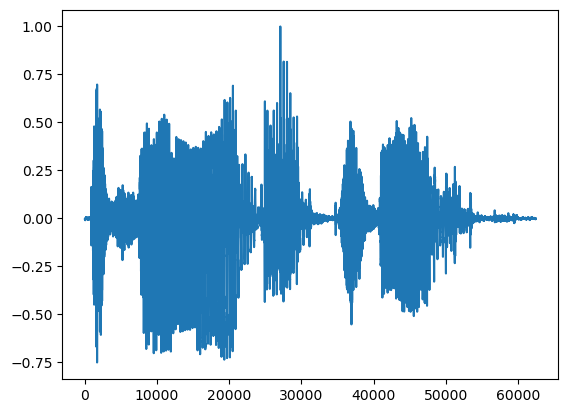

In [6]:
plt.plot(data)

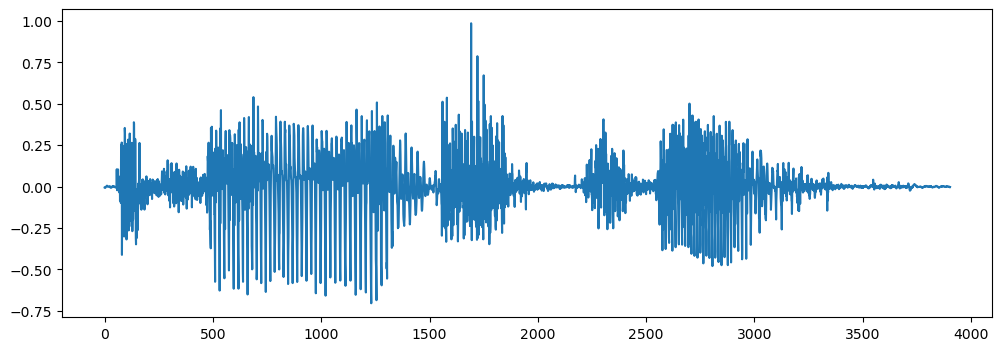

In [7]:
fig=plt.figure(0, (12,4))
plt.plot(data_ds)
plt.savefig('/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/1_the_bitter_lesson/graphics/waveform_1.svg')

In [8]:
cut_points=[0, 4500, 12000, 15500, 19000, 21500, 25000, 31500, 35000, 40500, 46000, 51500]
phones_1=["T", "EL", "M", "IY", "AH", "B", "AW", "T", "SH", "AY", "N", "UH"]

# Convert to downsampled indices
cut_points_ds = [cp // downsample_factor for cp in cut_points]

# Make sure we cover all data
if cut_points_ds[-1] < len(data_ds):
    cut_points_ds.append(len(data_ds))

In [9]:
cut_points_ds

[0, 281, 750, 968, 1187, 1343, 1562, 1968, 2187, 2531, 2875, 3218, 3904]

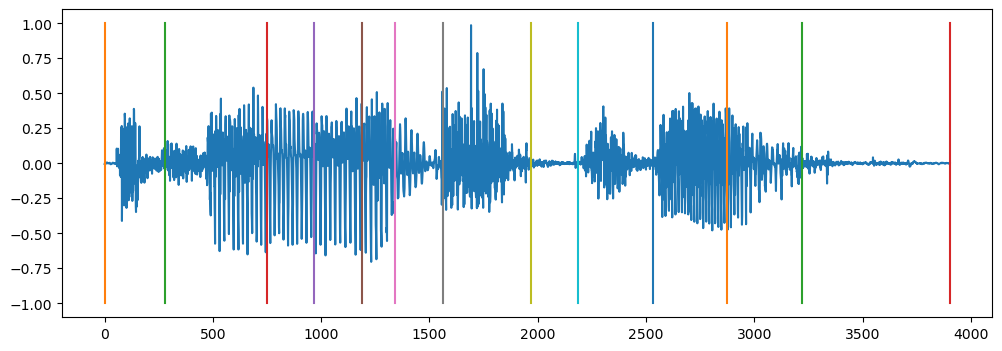

In [10]:
fig=plt.figure(0, (12,4))
plt.plot(data_ds)
for c in cut_points_ds:
    plt.plot([c, c], [-1, 1])

plt.savefig('/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/1_the_bitter_lesson/graphics/waveform_1a.svg')

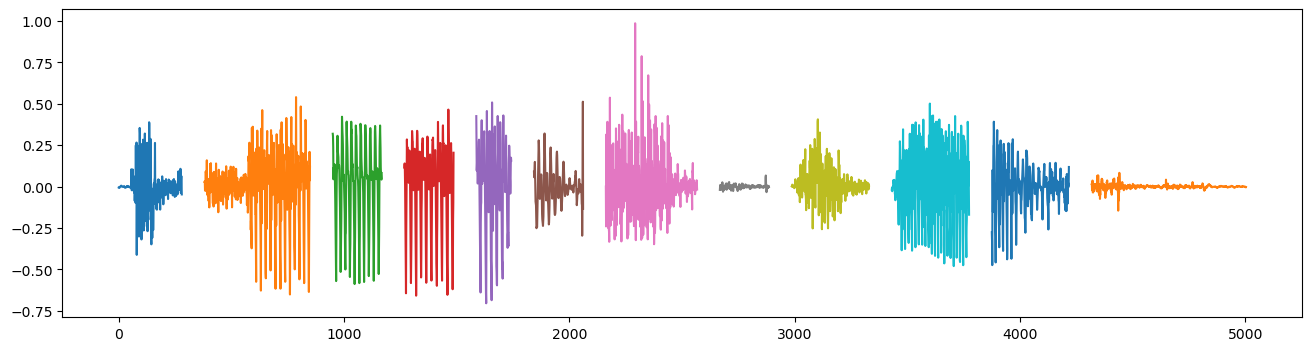

In [11]:
fig=plt.figure(0, (16,4))

spacing=100

for i in range(len(cut_points_ds) - 1):
    start_idx = cut_points_ds[i]
    end_idx = cut_points_ds[i + 1]
    n_samples = end_idx - start_idx
    
    # Width proportional to sample count
    # seg_width = (n_samples / total_samples) * axes_width
    
    segment_data = data_ds[start_idx:end_idx]
    plt.plot(np.arange(spacing*i+start_idx, spacing*i+end_idx), segment_data)

plt.savefig('/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/1_the_bitter_lesson/graphics/waveform_2.svg')

In [12]:
spectral_envelope_outputs_loaded = np.load(spectra_path, allow_pickle=True)
spectral_envelopes_loaded_dict = spectral_envelope_outputs_loaded.item()

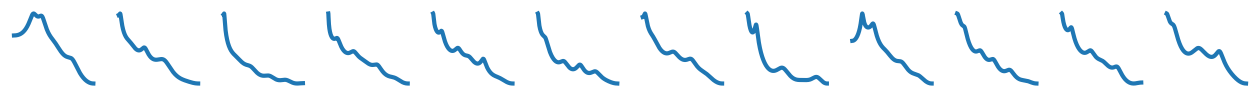

In [13]:
fig=plt.figure(0, (16,1))

for count, phone_key in enumerate(spectra_keys_2):
    curr_result = spectral_envelopes_loaded_dict.get(phone_key)
    w=curr_result.get("w")
    lpc_envelope = curr_result.get("lpc_envelope"),
    s=np.log10(lpc_envelope / np.max(lpc_envelope))[0]
    s=(s-s.min())/(s.max()-s.min())

    # plt.clf()
    fig.add_subplot(1, 12,count+1)
    plt.plot(w, s, linewidth=3)
    plt.axis('off')
    # plt.savefig('/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/1_the_bitter_lesson/graphics/spectrograms_1/spec'+str(count)+'.svg')


# plt.savefig('/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/1_the_bitter_lesson/graphics/spectrograms_1.svg')

## Ok, now phone graph

In [14]:
#Small graph configuration - Phone, node index, x coord, y coord
nodes=[['start', 0, 0, 0],
       ['T',     1, 4, 4], #Tell
       ['AH',    2, 6, 7],
       ['EL',    3, 8, 4], 
       ['M',     4, 11, 7], #Me
       ['IY',    5, 15, 7],
       ['IH',    6, 11, 1], #Us
       ['S',     7, 15, 1],
       ['OW',    8, 18, 4], #all
       ['EL',    9, 22, 4],
       ['A',     10, 26, 4], #About
       ['B',     11, 30, 4],
       ['AW',    12, 34, 4],
       ['T',     13, 38, 4],
       ['SH',    14, 41, 7], #CHINA
       ['AY',    15, 45, 7],
       ['N',     16, 49, 7],
       ['UH',    17, 53, 7],
       ['N',     18, 41, 1], #NIXON
       ['IH',    19, 45, 1],
       ['X',     20, 49, 1],
       ['EN',    21, 53, 1],
       ['G',     22, 4, -6], #GIVE
       ['IH',    23, 8, -6],
       ['V',     24, 12, -6],
       ['M',     25, 16, -6], #ME
       ['IY',    26, 20, -6],
       ['TH',    27, 24, -6], #THE
       ['UH',    28, 27, -3],
       ['EE',    29, 27, -9],
       ['H',     30, 31, -3], #HEADLINES
       ['AA',    31, 34.5, -3],
       ['D',     32, 38, -3],
       ['L',     33, 41, -3],
       ['AY',    34, 45, -3],
       ['N',     35, 49, -3],
       ['S',     36, 53, -3],
       ['N',     37, 31, -9], #NEWS
       ['OO',    38, 42, -9],
       ['S',     39, 53, -9],
       ['end',   40, 58, 0]
       ]

#Matches order of nodes
spectra_keys_1=['mc_sent1_tell_T', 'mc_sent1_tell_AH', 'mc_sent1_tell_EL', 
                'mc_sent1_me_M', 'mc_sent1_me_IY', 'mc_sent1_us_IH', 'mc_sent1_us_S', 
                'mc_sent1_all_OW', 'mc_sent1_all_EL', 'mc_sent1_about_A', 
                'mc_sent1_about_B', 'mc_sent1_about_AW', 'mc_sent1_about_T', 
                'mc_sent1_china_SH', 'mc_sent1_china_AY', 'mc_sent1_china_N', 'mc_sent1_china_UH', 
                'mc_sent1_nixon_N', 'mc_sent1_nixon_IH', 'mc_sent1_nixon_X', 'mc_sent1_nixon_EN', 
                'mc_sent2_give_G', 'mc_sent2_give_IH', 'mc_sent2_give_V', 
                'mc_sent2_me_M', 'mc_sent2_me_IY', 
                'mc_sent2_the_TH', 'mc_sent2_the_UH', 'mc_sent2_the_UH', #Duplicated for EE
                'mc_sent2_headlines_H', 'mc_sent2_headlines_AA', 'mc_sent2_headlines_D', 'mc_sent2_headlines_L', 'mc_sent2_headlines_AY', 'mc_sent2_headlines_N', 'mc_sent2_headlines_S',
                'mc_sent2_news_N', 'mc_sent2_news_OO', 'mc_sent2_news_S']

In [15]:
GREEN='#00a14a'

/var/folders/j5/ks68pdf144xgrs0s77q51qxw0000gn/T/ipykernel_1968/212196365.py:10: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  fig=plt.figure(0, (1,1))


AttributeError: 'NoneType' object has no attribute 'get'

<Figure size 640x480 with 0 Axes>

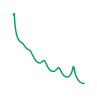

In [16]:
for count,k in enumerate(spectra_keys_1):
    curr_result = spectral_envelopes_loaded_dict.get(k)
    w=curr_result.get("w")
    lpc_envelope = curr_result.get("lpc_envelope"),
    s=np.log10(lpc_envelope / np.max(lpc_envelope))[0]
    s=(s-s.min())/(s.max()-s.min())

    plt.clf()
    # pl.add_subplot(1, 12,count+1)
    fig=plt.figure(0, (1,1))
    plt.plot(w, s, linewidth=1, color=GREEN)
    plt.axis('off')
    plt.savefig('/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/1_the_bitter_lesson/graphics/spectrograms_2/'+str(k)+'.svg', bbox_inches='tight')

In [17]:
k

'mc_sent2_the_EE'